# Engenharia de Feature e Atriibuto

In [72]:
import pandas as pd

In [73]:
df_obesidade = pd.read_csv('Obesity.csv')

In [74]:
df_obesidade.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [75]:
df_obesidade['Obesity'].unique()

<ArrowStringArray>
[      'Normal_Weight',  'Overweight_Level_I', 'Overweight_Level_II',
      'Obesity_Type_I', 'Insufficient_Weight',     'Obesity_Type_II',
    'Obesity_Type_III']
Length: 7, dtype: str

In [76]:
df_obesidade['MTRANS'].unique()

<ArrowStringArray>
['Public_Transportation', 'Walking', 'Automobile', 'Motorbike', 'Bike']
Length: 5, dtype: str

In [77]:
df_obesidade.isnull().sum()

Gender            0
Age               0
Height            0
Weight            0
family_history    0
FAVC              0
FCVC              0
NCP               0
CAEC              0
SMOKE             0
CH2O              0
SCC               0
FAF               0
TUE               0
CALC              0
MTRANS            0
Obesity           0
dtype: int64

In [78]:
df_obesidade.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

<Axes: >

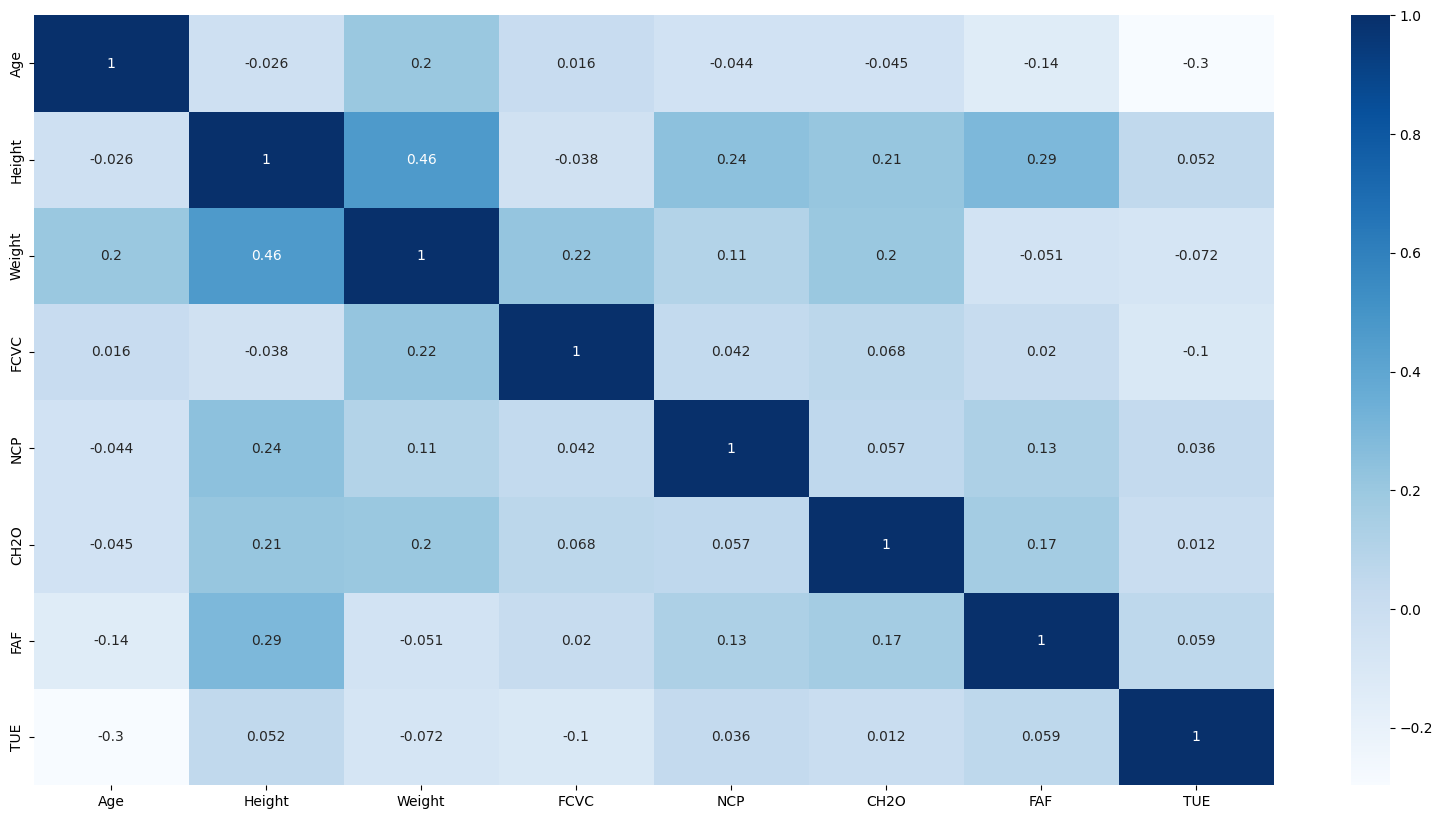

In [80]:
## Essa tarefa não surgi efeito para entender a corelação quando não consideramos a variável categórica, 
## então vamos considerar apenas as variáveis numéricas para entender a correlação entre elas.

corr = df_obesidade.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(20, 10))
sns.heatmap(corr, cmap="Blues", annot=True)

In [81]:
df_obesidade.drop(columns=['Height', 'Weight'], inplace=True)

In [82]:
df_obesidade.head()

,Gender,Age,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [83]:
from sklearn.preprocessing import OneHotEncoder

nominais = [
    'Gender',
    'family_history',
    'FAVC',
    'SCC',
    'SMOKE',
    'MTRANS'
]

# fit_transform retorna novos dados; ele não altera o DataFrame original.
one_hot_encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    dtype=int
)

nominais_codificadas = one_hot_encoder.fit_transform(
    df_obesidade[nominais]
).toarray()

df_nominais_codificadas = pd.DataFrame(
    nominais_codificadas,
    columns=one_hot_encoder.get_feature_names_out(nominais),
    index=df_obesidade.index
)

# Remove as colunas categóricas originais e inclui as colunas do One Hot Encoding.
df_obesidade = pd.concat(
    [df_obesidade.drop(columns=nominais), df_nominais_codificadas],
    axis=1
)


In [84]:
from sklearn.preprocessing import OrdinalEncoder

ordinais = ['CAEC', 'CALC']

ordem = [['no', 'Sometimes', 'Frequently', 'Always'],
          ['no', 'Sometimes', 'Frequently', 'Always']]

encoder = OrdinalEncoder(categories=ordem)

df_obesidade[ordinais] = encoder.fit_transform(df_obesidade[ordinais])

In [85]:
df_obesidade.head()

,Age,FCVC,NCP,CAEC,CH2O,FAF,TUE,CALC,Obesity,Gender_Male,family_history_yes,FAVC_yes,SCC_yes,SMOKE_yes,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.0,2.0,3.0,1.0,2.0,0.0,1.0,0.0,Normal_Weight,0,1,0,0,0,0,0,1,0
1,21.0,3.0,3.0,1.0,3.0,3.0,0.0,1.0,Normal_Weight,0,1,0,1,1,0,0,1,0
2,23.0,2.0,3.0,1.0,2.0,2.0,1.0,2.0,Normal_Weight,1,1,0,0,0,0,0,1,0
3,27.0,3.0,3.0,1.0,2.0,2.0,0.0,2.0,Overweight_Level_I,1,0,0,0,0,0,0,0,1
4,22.0,2.0,1.0,1.0,2.0,0.0,0.0,1.0,Overweight_Level_II,1,0,0,0,0,0,0,1,0


In [86]:
df_obesidade['CAEC'].unique()

array([1., 2., 3., 0.])

In [87]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_obesidade['Obesity'] = le.fit_transform(df_obesidade['Obesity'])

In [88]:
df_obesidade.head()

,Age,FCVC,NCP,CAEC,CH2O,FAF,TUE,CALC,Obesity,Gender_Male,family_history_yes,FAVC_yes,SCC_yes,SMOKE_yes,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.0,2.0,3.0,1.0,2.0,0.0,1.0,0.0,1,0,1,0,0,0,0,0,1,0
1,21.0,3.0,3.0,1.0,3.0,3.0,0.0,1.0,1,0,1,0,1,1,0,0,1,0
2,23.0,2.0,3.0,1.0,2.0,2.0,1.0,2.0,1,1,1,0,0,0,0,0,1,0
3,27.0,3.0,3.0,1.0,2.0,2.0,0.0,2.0,5,1,0,0,0,0,0,0,0,1
4,22.0,2.0,1.0,1.0,2.0,0.0,0.0,1.0,6,1,0,0,0,0,0,0,1,0


# Contruindo a Pipeline Machine Learning Treino e Teste

In [89]:
from sklearn.model_selection import train_test_split

In [90]:
SEED = 1561651

In [91]:
treino_df_obesidade, test_df_obesidade = train_test_split(df_obesidade, test_size=0.2, random_state=SEED)

In [92]:
treino_df_obesidade.shape

(1688, 18)

In [93]:
test_df_obesidade.shape

(423, 18)

In [94]:
#%pip install imbalanced-learn

In [95]:
from sklearn.base import BaseEstimator, TransformerMixin
from imblearn.over_sampling import SMOTE

In [96]:
class Oversample(BaseEstimator,TransformerMixin):
    def __init__(self):
        pass
    def fit(self,df):
        return self
    def transform(self,df):
        if 'Obesity' in df.columns:
            # função smote para superamostrar a classe minoritária para corrigir os dados desbalanceados
            oversample = SMOTE(sampling_strategy='minority')
            X_bal, y_bal = oversample.fit_resample(df.loc[:, df.columns != 'Obesity'], df['Obesity'])
            df_bal = pd.concat([pd.DataFrame(X_bal),pd.DataFrame(y_bal)],axis=1)
            return df_bal
        else:
            print("O target não está no DataFrame")
            return df

In [97]:
from sklearn.pipeline import Pipeline

In [98]:
def pipeline(df):
    pipeline = Pipeline([
        ('oversample', Oversample())
    ])
    df_pipeline = pipeline.fit_transform(df)
    return df_pipeline

In [99]:
train = pipeline(treino_df_obesidade)

In [100]:
train.head()

,Age,FCVC,NCP,CAEC,CH2O,FAF,TUE,CALC,Gender_Male,family_history_yes,FAVC_yes,SCC_yes,SMOKE_yes,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,Obesity
0,20.147114,3.0,1.0,2.0,1.322669,0.000000,0.478676,1.0,0,0,1,0,0,0,0,1,0,0
1,20.880161,2.0,3.0,1.0,2.000000,1.666390,1.443212,0.0,1,1,1,0,0,0,0,1,0,6
2,23.694840,3.0,3.0,1.0,2.495961,0.189831,0.652289,1.0,0,1,1,0,0,0,0,1,0,4
3,25.993154,3.0,3.0,1.0,2.613504,0.067985,0.778632,1.0,0,1,1,0,0,0,0,1,0,4
4,21.412434,3.0,3.0,1.0,1.484938,0.742250,0.604692,1.0,0,1,1,0,0,0,0,1,0,4


# Treinamento e avaliação de modelos

Obesity possui **7 classes**, portanto a avaliação é multiclasse. O AUC é calculado
por One-vs-Rest (OvR) com média macro. O KS é calculado para cada classe contra as
demais e resumido pela média.

Para escolher o modelo, priorize **F1 macro** e **acurácia balanceada**, pois essas
métricas dão o mesmo peso a todas as classes.


In [101]:
from IPython.display import display
from scipy import stats
from sklearn import metrics
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    precision_recall_fscore_support,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.preprocessing import label_binarize

# O SMOTE foi aplicado somente ao treino; o teste mantém a distribuição original.
X_train = train.drop(columns='Obesity')
y_train = train['Obesity'].astype(int)
X_test = test_df_obesidade.drop(columns='Obesity')
y_test = test_df_obesidade['Obesity'].astype(int)

classes_obesidade = np.arange(len(le.classes_))
nomes_classes = le.classes_.astype(str)
mapa_classes = pd.DataFrame({
    'Código': classes_obesidade,
    'Classe': nomes_classes
})
print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')
display(mapa_classes)

# Uma linha por modelo, ordenada pelo F1 macro.
historico_modelos = pd.DataFrame()


def roda_modelo(modelo, nome=None, exibir_graficos=True):
    """Treina e avalia um classificador multiclasse de obesidade."""
    global historico_modelos

    nome_modelo = nome or modelo.__class__.__name__
    print(f'\n{"-" * 30} {nome_modelo} {"-" * 30}\n')

    modelo.fit(X_train, y_train)
    predicao = modelo.predict(X_test)

    acuracia = accuracy_score(y_test, predicao)
    acuracia_balanceada = balanced_accuracy_score(y_test, predicao)
    precisao, recall, f1, _ = precision_recall_fscore_support(
        y_test, predicao,
        labels=classes_obesidade,
        average='macro',
        zero_division=0
    )

    print(f'Acurácia:             {acuracia:.4f}')
    print(f'Acurácia balanceada:  {acuracia_balanceada:.4f}')
    print(f'Precisão macro:       {precisao:.4f}')
    print(f'Recall macro:         {recall:.4f}')
    print(f'F1 macro:             {f1:.4f}')

    auc_macro = np.nan
    ks_medio = np.nan
    probabilidades = None

    if hasattr(modelo, 'predict_proba'):
        proba_modelo = modelo.predict_proba(X_test)
        probabilidades = np.zeros(
            (len(X_test), len(classes_obesidade)), dtype=float
        )

        # Garante que as probabilidades sigam a ordem do LabelEncoder.
        for coluna, classe in enumerate(modelo.classes_):
            indice = np.where(classes_obesidade == int(classe))[0]
            if indice.size:
                probabilidades[:, indice[0]] = proba_modelo[:, coluna]

        try:
            auc_macro = roc_auc_score(
                y_test,
                probabilidades,
                labels=classes_obesidade,
                multi_class='ovr',
                average='macro'
            )
            print(f'AUC macro OvR:        {auc_macro:.4f}')
        except ValueError as erro:
            print(f'AUC não calculado: {erro}')

        # KS multiclasse: cada classe contra todas as demais.
        linhas_ks = []
        y_array = y_test.to_numpy()
        for indice, (classe, nome_classe) in enumerate(
            zip(classes_obesidade, nomes_classes)
        ):
            positivos = y_array == classe
            if positivos.any() and (~positivos).any():
                teste_ks = stats.ks_2samp(
                    probabilidades[positivos, indice],
                    probabilidades[~positivos, indice]
                )
                linhas_ks.append({
                    'Classe': nome_classe,
                    'KS': teste_ks.statistic,
                    'p-valor': teste_ks.pvalue
                })

        tabela_ks = pd.DataFrame(linhas_ks)
        if not tabela_ks.empty:
            ks_medio = tabela_ks['KS'].mean()
            print(f'KS médio OvR:         {ks_medio:.4f}')
            print('\nKS por classe (One-vs-Rest)')
            display(tabela_ks.style.format({
                'KS': '{:.4f}', 'p-valor': '{:.3e}'
            }))
    else:
        print(
            'AUC, KS e ROC não calculados: '
            'o modelo não possui predict_proba().'
        )

    print('\nClassification Report\n')
    print(classification_report(
        y_test,
        predicao,
        labels=classes_obesidade,
        target_names=nomes_classes,
        digits=4,
        zero_division=0
    ))

    if exibir_graficos:
        fig, ax = plt.subplots(figsize=(11, 9))
        metrics.ConfusionMatrixDisplay.from_predictions(
            y_test,
            predicao,
            labels=classes_obesidade,
            display_labels=nomes_classes,
            normalize='true',
            cmap=plt.cm.Blues,
            values_format='.2f',
            xticks_rotation=45,
            ax=ax
        )
        ax.set_title(
            f'Matriz de confusão normalizada — {nome_modelo}',
            fontsize=15,
            fontweight='bold'
        )
        ax.set_xlabel('Classe predita')
        ax.set_ylabel('Classe verdadeira')
        ax.grid(False)
        plt.tight_layout()
        plt.show()

        if probabilidades is not None:
            y_binario = label_binarize(y_test, classes=classes_obesidade)
            fig, ax = plt.subplots(figsize=(11, 8))
            for indice, nome_classe in enumerate(nomes_classes):
                RocCurveDisplay.from_predictions(
                    y_binario[:, indice],
                    probabilidades[:, indice],
                    name=nome_classe,
                    ax=ax
                )
            ax.plot([0, 1], [0, 1], 'k--', label='Aleatório')
            ax.set_title(f'Curvas ROC OvR — {nome_modelo}')
            ax.legend(loc='lower right', fontsize=8)
            ax.grid(alpha=0.25)
            plt.tight_layout()
            plt.show()

    resultado = {
        'Modelo': nome_modelo,
        'Acurácia': acuracia,
        'Acurácia balanceada': acuracia_balanceada,
        'Precisão macro': precisao,
        'Recall macro': recall,
        'F1 macro': f1,
        'AUC macro OvR': auc_macro,
        'KS médio OvR': ks_medio
    }

    # Uma nova execução com o mesmo nome substitui a linha anterior.
    if not historico_modelos.empty:
        historico_modelos = historico_modelos[
            historico_modelos['Modelo'] != nome_modelo
        ]
    historico_modelos = pd.concat(
        [historico_modelos, pd.DataFrame([resultado])],
        ignore_index=True
    ).sort_values('F1 macro', ascending=False).reset_index(drop=True)

    print('\nComparação dos modelos já executados')
    display(historico_modelos.style.format({
        coluna: '{:.4f}'
        for coluna in historico_modelos.columns
        if coluna != 'Modelo'
    }))
    return resultado


Treino: (1758, 17) | Teste: (423, 17)


,Código,Classe
0,0,Insufficient_Weight
1,1,Normal_Weight
2,2,Obesity_Type_I
3,3,Obesity_Type_II
4,4,Obesity_Type_III
5,5,Overweight_Level_I
6,6,Overweight_Level_II


## Modelos candidatos

Execute uma chamada de roda_modelo por vez. A regressão logística usa StandardScaler
em uma pipeline por ser sensível à escala.



------------------------------ HistGradientBoosting ------------------------------

Acurácia:             0.8440
Acurácia balanceada:  0.8448
Precisão macro:       0.8446
Recall macro:         0.8448
F1 macro:             0.8433
AUC macro OvR:        0.9731
KS médio OvR:         0.8810

KS por classe (One-vs-Rest)


,Classe,KS,p-valor
0,Insufficient_Weight,0.8685,1.508e-43
1,Normal_Weight,0.8759,3.911e-42
2,Obesity_Type_I,0.8435,1.565e-44
3,Obesity_Type_II,0.9810,1.748e-61
4,Obesity_Type_III,0.9683,7.452e-64
5,Overweight_Level_I,0.8501,9.184e-38
6,Overweight_Level_II,0.7796,2.390e-33



Classification Report

                     precision    recall  f1-score   support

Insufficient_Weight     0.8966    0.8525    0.8739        61
      Normal_Weight     0.6615    0.7544    0.7049        57
     Obesity_Type_I     0.8551    0.8429    0.8489        70
    Obesity_Type_II     0.8852    0.9818    0.9310        55
   Obesity_Type_III     1.0000    0.9683    0.9839        63
 Overweight_Level_I     0.8364    0.8364    0.8364        55
Overweight_Level_II     0.7778    0.6774    0.7241        62

           accuracy                         0.8440       423
          macro avg     0.8446    0.8448    0.8433       423
       weighted avg     0.8467    0.8440    0.8440       423



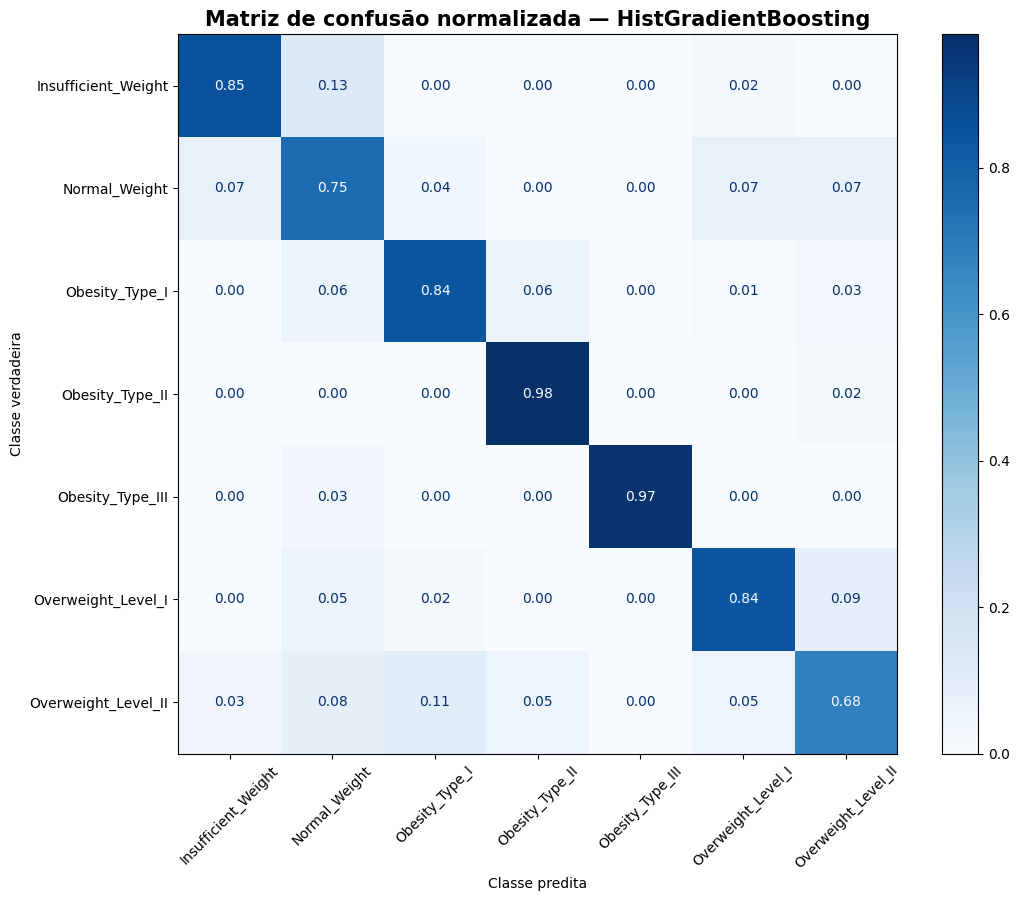

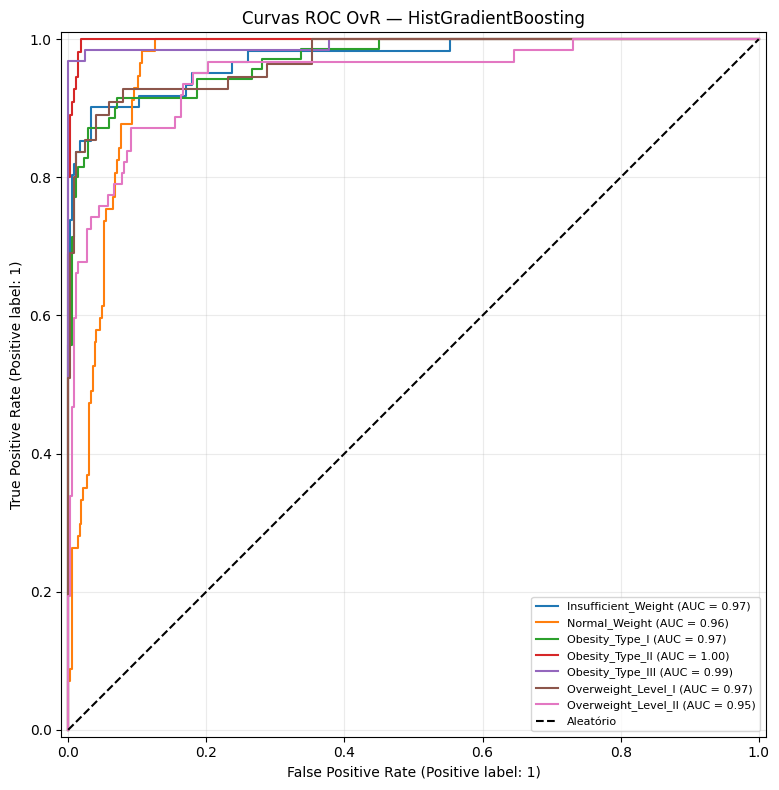


Comparação dos modelos já executados


,Modelo,Acurácia,Acurácia balanceada,Precisão macro,Recall macro,F1 macro,AUC macro OvR,KS médio OvR
0,HistGradientBoosting,0.8440,0.8448,0.8446,0.8448,0.8433,0.9731,0.8810


{'Modelo': 'HistGradientBoosting',
 'Acurácia': 0.8439716312056738,
 'Acurácia balanceada': 0.8447938950624803,
 'Precisão macro': 0.8446499950321809,
 'Recall macro': 0.8447938950624803,
 'F1 macro': 0.8433136419752636,
 'AUC macro OvR': 0.9730855255545138,
 'KS médio OvR': np.float64(0.8809697958363666)}

In [102]:
from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

modelos = {
    'Regressão Logística': make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=3000, random_state=SEED)
    ),
    'Árvore de Decisão': DecisionTreeClassifier(random_state=SEED),
    'Random Forest': RandomForestClassifier(
        n_estimators=400, random_state=SEED, n_jobs=-1
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=400, random_state=SEED, n_jobs=-1
    ),
    'HistGradientBoosting': HistGradientBoostingClassifier(
        random_state=SEED
    ),
    'XGBClassifier': XGBClassifier(
        random_state=SEED
    )
}

# Descomente e execute UM modelo por vez:
# roda_modelo(modelos['Regressão Logística'], 'Regressão Logística')
# roda_modelo(modelos['Árvore de Decisão'], 'Árvore de Decisão')
# roda_modelo(modelos['Random Forest'], 'Random Forest')
# roda_modelo(modelos['Extra Trees'], 'Extra Trees')
roda_modelo(modelos['HistGradientBoosting'], 'HistGradientBoosting')
# roda_modelo(modelos['XGBClassifier'], 'XGBClassifier')


In [103]:
import joblib
modelo_hgb = modelos['HistGradientBoosting']

In [104]:
joblib.dump(modelo_hgb, 'hgb.joblib')

['hgb.joblib']

In [105]:
!pip show scikit-learn

Name: scikit-learn
Version: 1.7.2
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License-Expression: BSD-3-Clause
Location: c:\users\renat\appdata\local\programs\python\python310\lib\site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: imbalanced-learn, obesity-data-api, sklearn-compat
